In [1]:
%load_ext autoreload
%autoreload 2

In [1]:
import os
import sys

sys.path.append(os.path.expanduser('~/Code/wmh-mc-seg'))  # For VSCode

In [2]:
from src.datamodules import WMHDataModule
import os
import numpy as np
from notebooks.metrics.utils import (dice_vs_entropy, dice, entropy_boxes,
                                     mcdropout_boxes, uncertainty_confusion,
                                     entropy_volume_ranges, reliability_plots,
                                     probability_volume_ranges, 
                                     error_retention_curve, hausdorff)

In [3]:
data_root = os.path.expanduser('~/Code/datasets/wmh/')
centers_train = ['UtAmSi']
centers_test = ['Utrecht', 'Amsterdam', 'Singapore', 'UMCL']
group_test = {'UtAmSi': ['Utrecht', 'Amsterdam', 'Singapore']}  # Group for plot

losses = ['Dice', 'Dice_MEEP', 'Dice_KL']
runs_to_compare = {
    'Dice UtAmSi': 'training_Utrecht_Amsterdam_Singapore_Dice_3011_best',
    # 'Dice_MEALL UtAmSi': not trained,
    'Dice_MEEP UtAmSi': 'training_Utrecht_Amsterdam_Singapore_DICEMEEP_5945_best',
    'Dice_KL UtAmSi': 'training_Utrecht_Amsterdam_Singapore_dicekl_5713_best',
}

In [4]:
test_splits = {}
for center in ['Utrecht', 'Amsterdam', 'Singapore']:
    dm = WMHDataModule(data_root, 1, f'training:{center}', [.7, .1, .2],
                       seed=42)
    _, _, ts_spl = dm.generate_splits()
    test_splits[center] = ts_spl

test_splits['UMCL'] = WMHDataModule(
    data_root, 1, 'training:UMCL', [0, 0, 1]).generate_splits()[2]

In [5]:
for key, val in group_test.items():  # Group test datasets if needed
    test_splits[key] = []
    for center in val:
        test_splits[key] += test_splits[center]
        del test_splits[center]
        # Remove center from centers_test
        centers_test.remove(center)
    centers_test.append(key)

In [6]:
plot_data = {
    'centers_train': centers_train,
    'runs_to_compare': runs_to_compare,
    'centers_test': centers_test,
    'test_splits': test_splits,
    'losses': losses,
}

## Plots

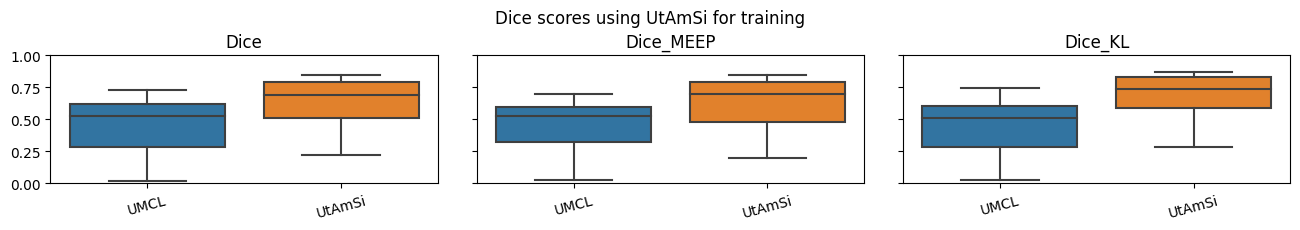

In [8]:
dice(plot_data, use_brain_mask=False)

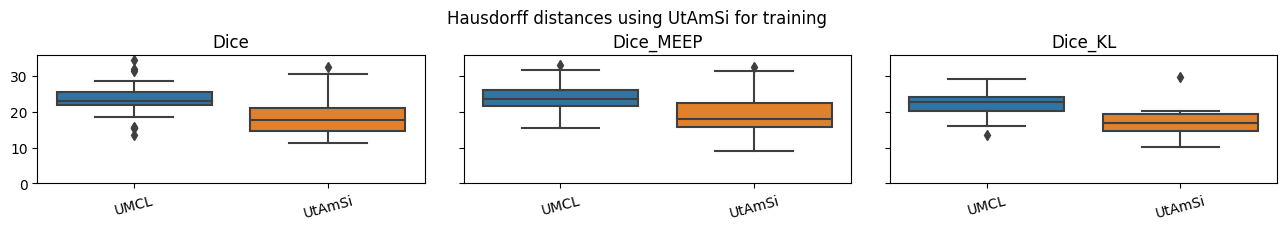

In [7]:
hausdorff(plot_data, use_brain_mask=False)

Dice UMCL - Pearson correlation coefficient: -0.949
Dice UtAmSi - Pearson correlation coefficient: -0.875
Dice_MEEP UMCL - Pearson correlation coefficient: -0.925
Dice_MEEP UtAmSi - Pearson correlation coefficient: -0.796
Dice_KL UMCL - Pearson correlation coefficient: -0.956
Dice_KL UtAmSi - Pearson correlation coefficient: -0.894
Dice - Pearson correlation coefficient: -0.923
Dice_MEEP - Pearson correlation coefficient: -0.879
Dice_KL - Pearson correlation coefficient: -0.934


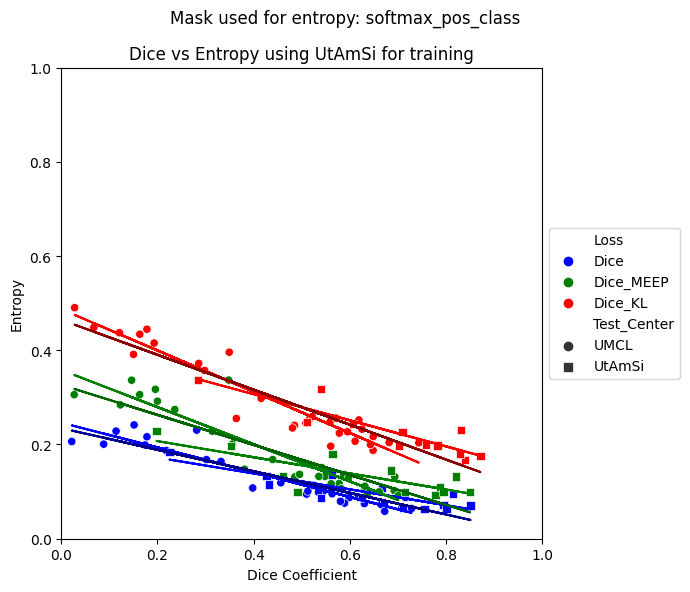

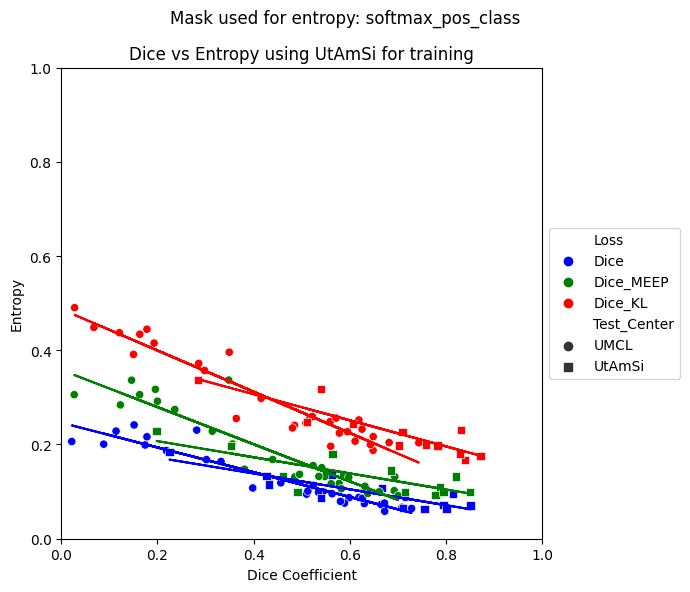

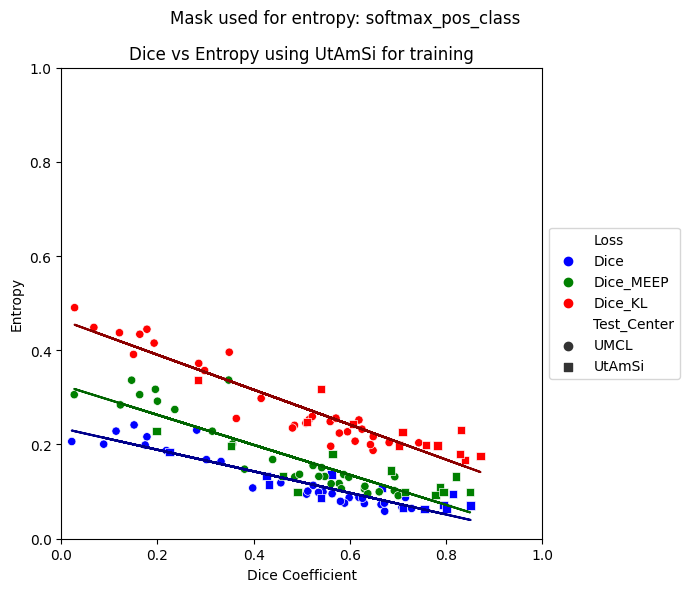

In [9]:
dice_vs_entropy(plot_data, m_type='softmax_pos_class',
                loss_centers_tendencies=True, loss_tendencies=True,
                print_ideal=False, print_metrics=True)
dice_vs_entropy(plot_data, m_type='softmax_pos_class',
                loss_centers_tendencies=True, loss_tendencies=False,
                print_ideal=False, print_metrics=False)
dice_vs_entropy(plot_data, m_type='softmax_pos_class',
                loss_centers_tendencies=False, loss_tendencies=True,
                print_ideal=False, print_metrics=False)

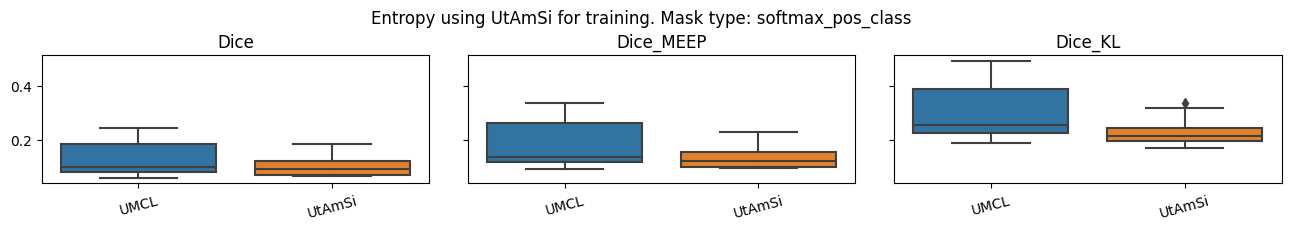

In [10]:
entropy_boxes(plot_data, m_type='softmax_pos_class')

In [11]:
mcdropout_boxes(plot_data)

FileNotFoundError: No such file or no access: '/home/fmatzkin/Code/datasets/wmh/training/UMCL/25/pred_mc_uncertmc_training_Utrecht_Amsterdam_Singapore_DICEMEEP_5945_best.nii.gz'

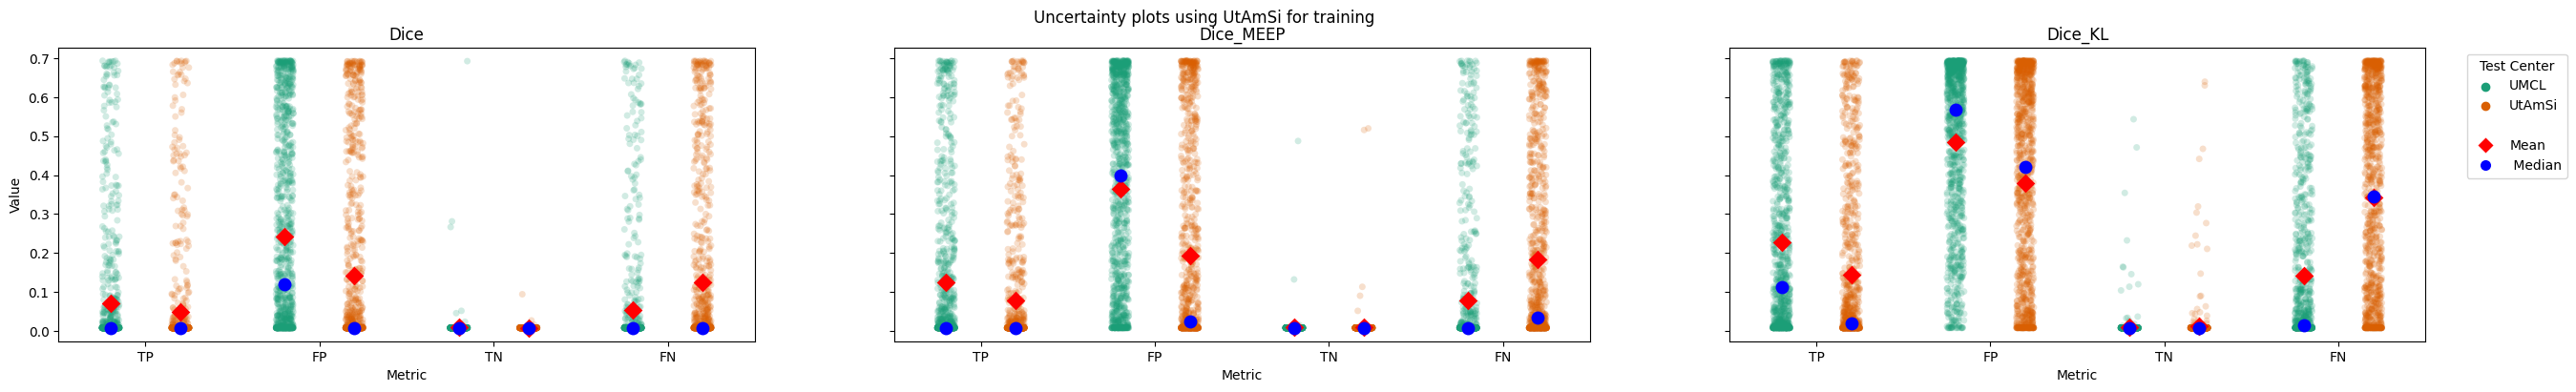

In [12]:
uncertainty_confusion(plot_data, n_samples=1000)

In [13]:
volume_ranges = [(0, 5), (5, 15), (15, np.inf)]

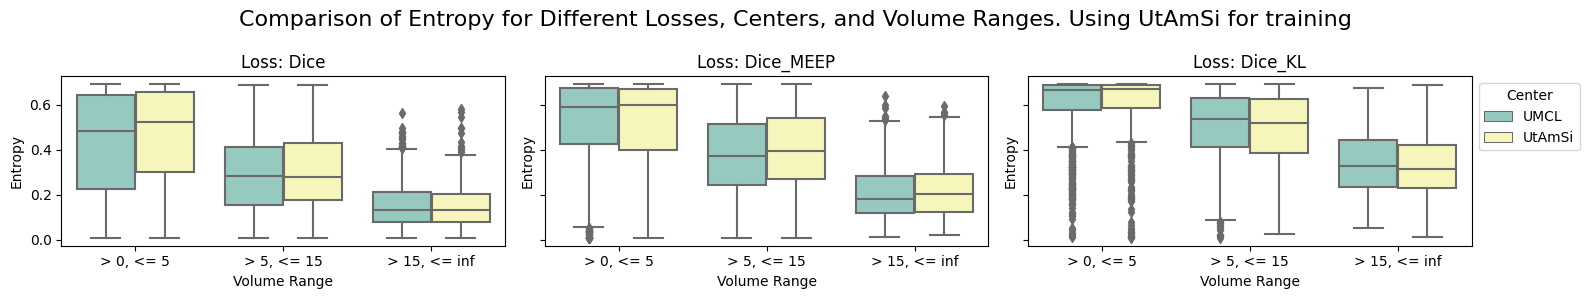

In [14]:
entropy_volume_ranges(plot_data, volume_ranges)

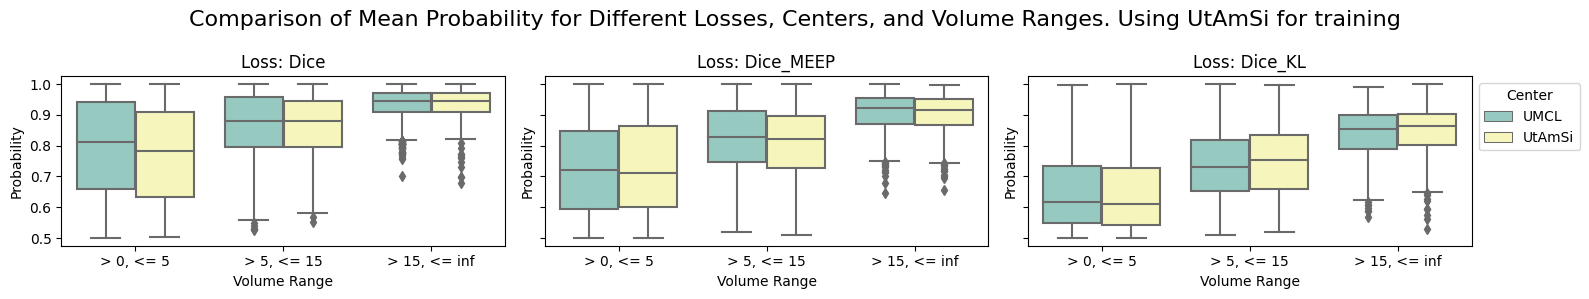

In [15]:
probability_volume_ranges(plot_data, volume_ranges)

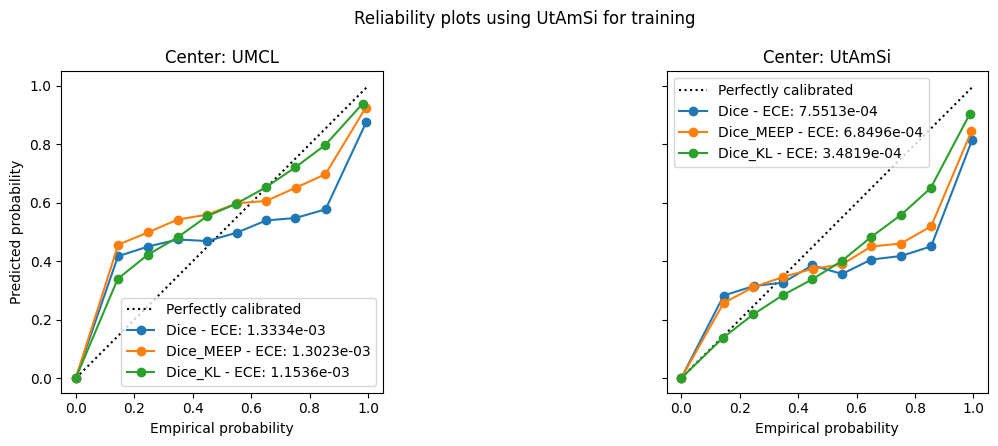

In [7]:
reliability_plots(plot_data)

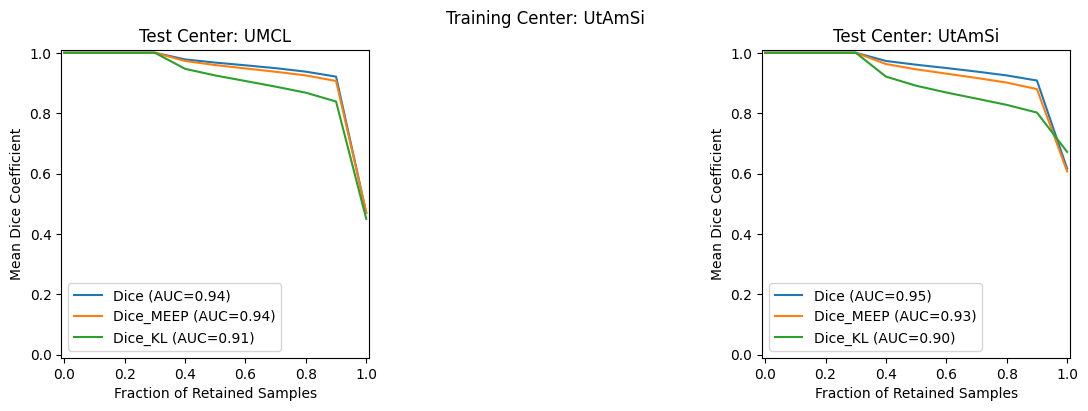

In [7]:
error_retention_curve(plot_data)